## Imports

In [7]:
#imports 
from stardist.models import StarDist2D
import numpy as np
from tifffile import imwrite, imread
from pathlib import Path
from skimage.measure import label

import os
import numpy as np
import tifffile
from stardist.models import StarDist2D
from stardist.matching import matching_dataset
from csbdeep.utils import normalize

import os
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from skimage.morphology import white_tophat, disk
from csbdeep.utils import normalize
from stardist.models import StarDist2D
import re


In [28]:
#plotting parameters. Adjustable
plt.rcParams["font.family"] = 'Arial'
plt.rcParams["lines.linewidth"] = 1
plt.rcParams["lines.linestyle"] = '-'
plt.rcParams["axes.titlesize"] = 24
plt.rcParams["axes.labelsize"] = 20

plt.rcParams["legend.fontsize"] = 16

plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16

plt.rcParams["xtick.major.size"] = 5
plt.rcParams["xtick.major.size"] = 5

plt.rcParams["axes.grid"] = False
plt.rcParams["axes.grid.which"] = 'major'

plt.rcParams["legend.loc"] = "upper left"

## plot

In [33]:
#import
raw_dir = "fluorescence_data"
mask_dir = "manual_masks/stardist_masks"
save_dir = "stardist_masks"

# List files in the directory to verify what is actually there
print(os.listdir(raw_dir))
print(os.listdir(mask_dir))

def get_id(fname):
    # re.search looks for a pattern within the filename (fname)
    # \d{5} means "find exactly 5 digits in a row"
    match = re.search(r'(\d{5})', fname)
    
    # If it finds the numbers, return them (e.g., "00001")
    # If it doesn't find them, return None so the script doesn't crash
    return match.group(1) if match else None

raw_files = sorted([f for f in os.listdir(raw_dir) if f.endswith('.tif')])
mask_map = {get_id(m): m for m in os.listdir(mask_dir) if get_id(m)}

['Image_Hn249_150ms_(00001).tif', 'Image_Hn249_150ms_(00002).tif', 'Image_Hn249_150ms_(00003).tif', 'Image_Hn249_150ms_(00004).tif', 'Image_Hn249_150ms_(00005).tif', 'Image_Hn249_150ms_(00006).tif', 'Image_Hn249_150ms_(00007).tif', 'Image_Hn249_150ms_(00008).tif', 'Image_Hn249_150ms_(00009).tif', 'Image_Hn249_150ms_(00010).tif', 'Image_Hn249_150ms_(00011).tif', 'Image_Hn249_150ms_(00012).tif', 'Image_Hn249_150ms_(00013).tif', 'Image_Hn249_150ms_(00014).tif', 'Image_Hn249_150ms_(00015).tif', 'Image_Hn249_150ms_(00016).tif', 'Image_Hn249_150ms_(00017).tif', 'Image_Hn249_150ms_(00018).tif', 'Image_Hn249_150ms_(00019).tif', 'Image_Hn249_150ms_(00020).tif', 'Image_Hn249_150ms_(00021).tif', 'Image_Hn249_150ms_(00022).tif', 'Image_Hn249_150ms_(00023).tif', 'Image_Hn249_150ms_(00024).tif', 'Image_Hn249_150ms_(00025).tif', 'Image_Hn249_150ms_(00026).tif', 'Image_Hn249_150ms_(00027).tif', 'Image_Hn249_150ms_(00028).tif', 'Image_Hn249_150ms_(00029).tif', 'Image_Hn249_150ms_(00030).tif', 'Image_Hn

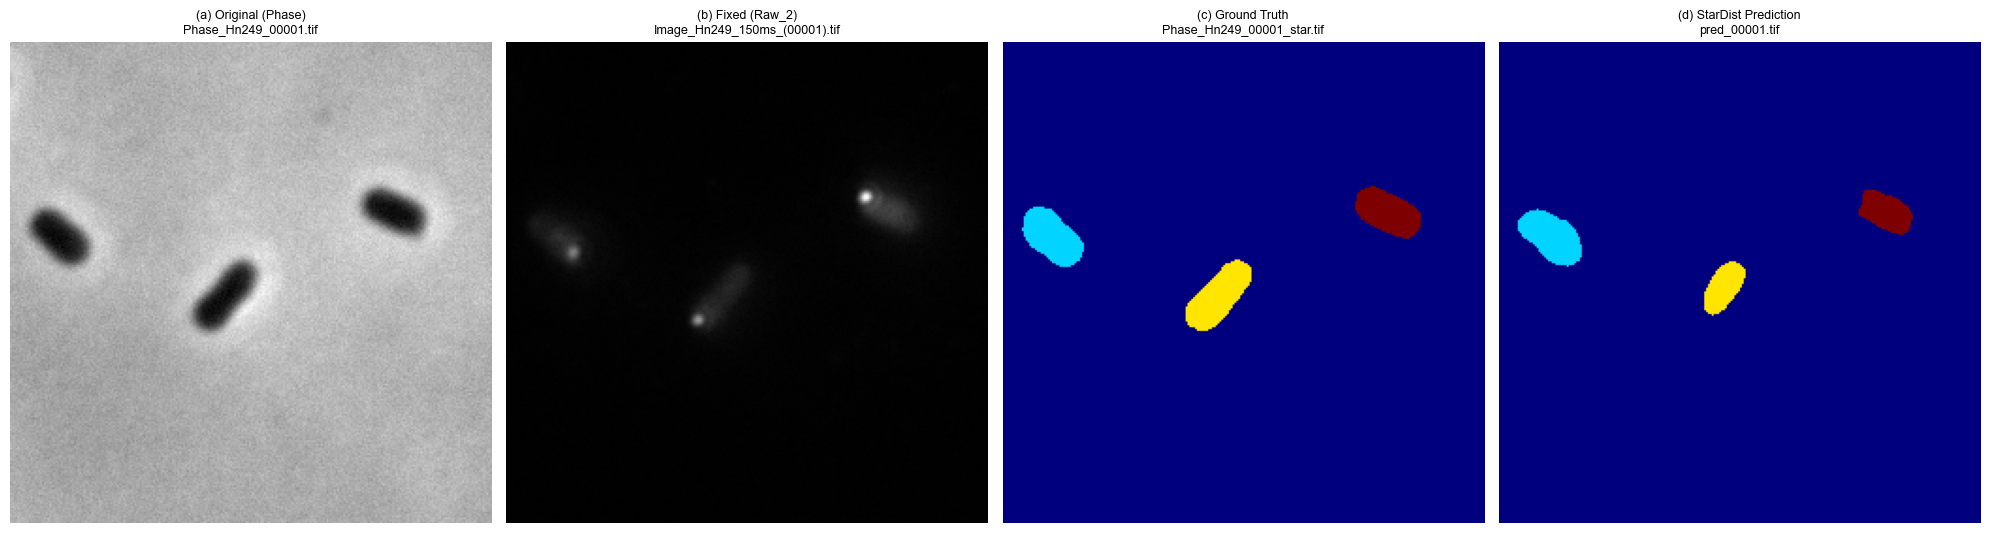

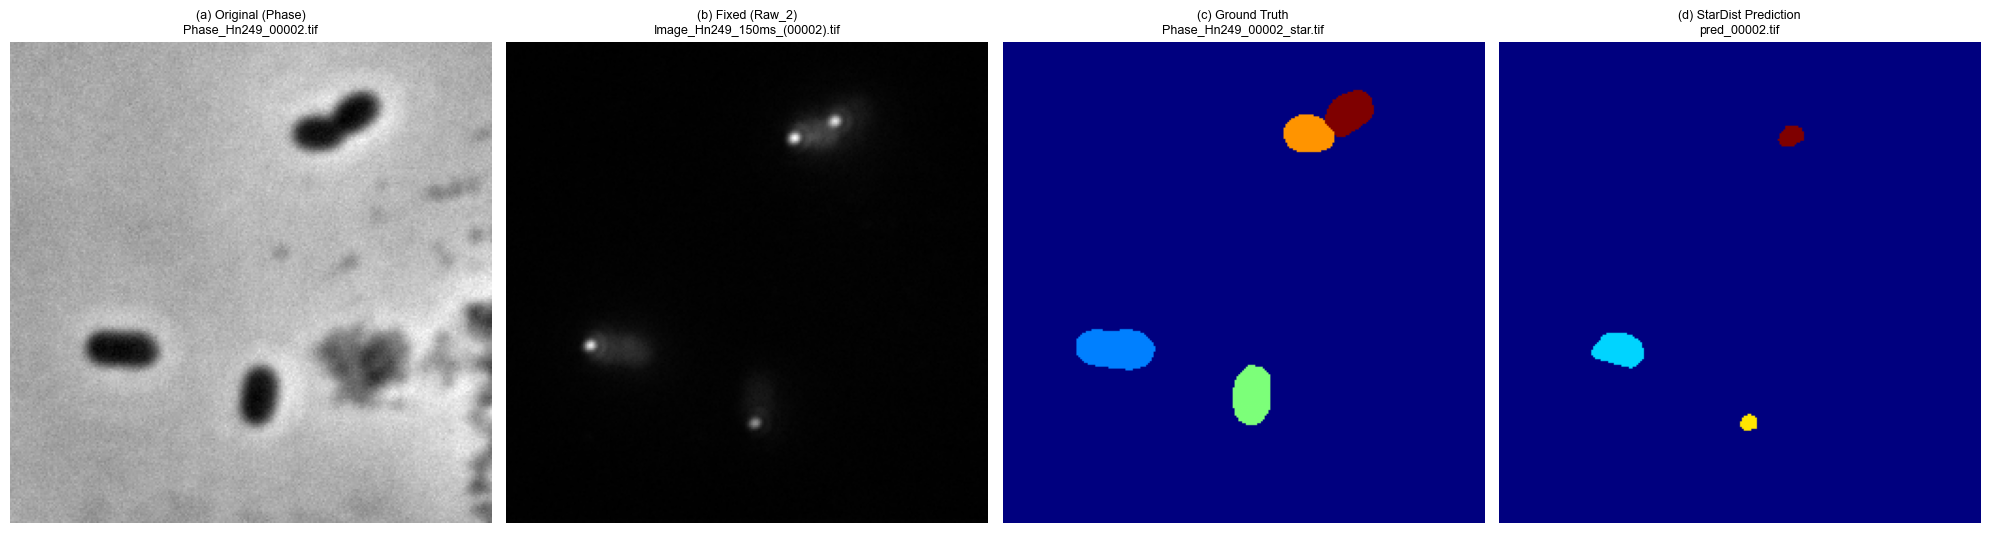

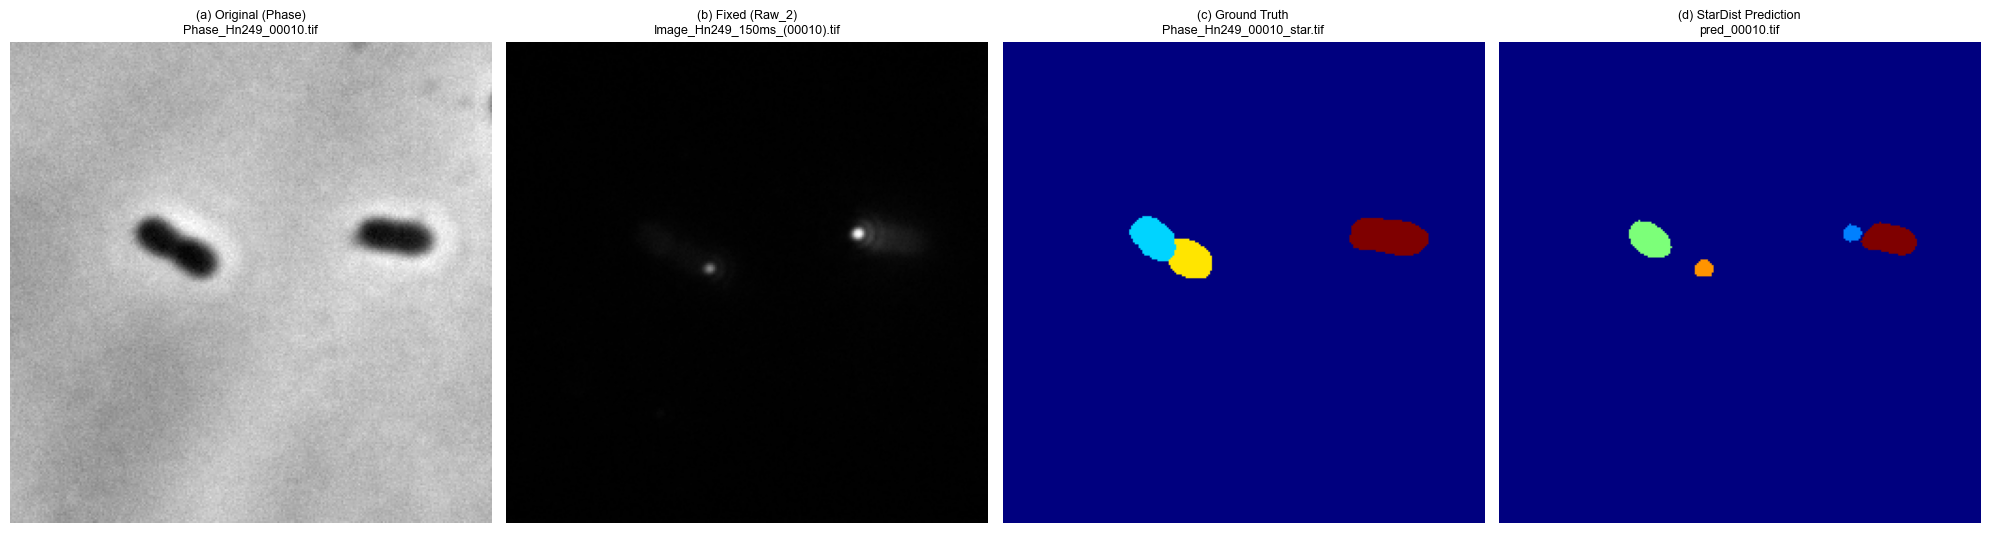

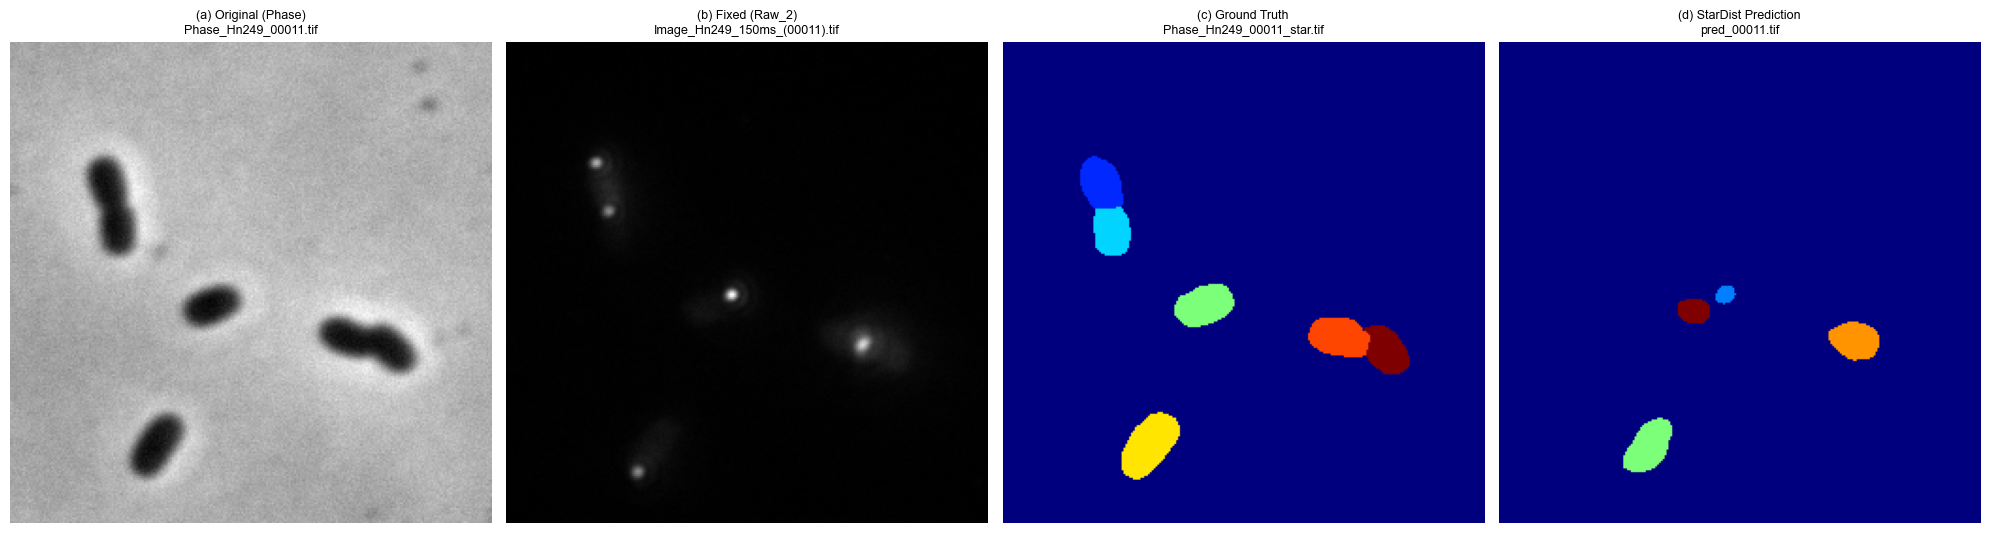

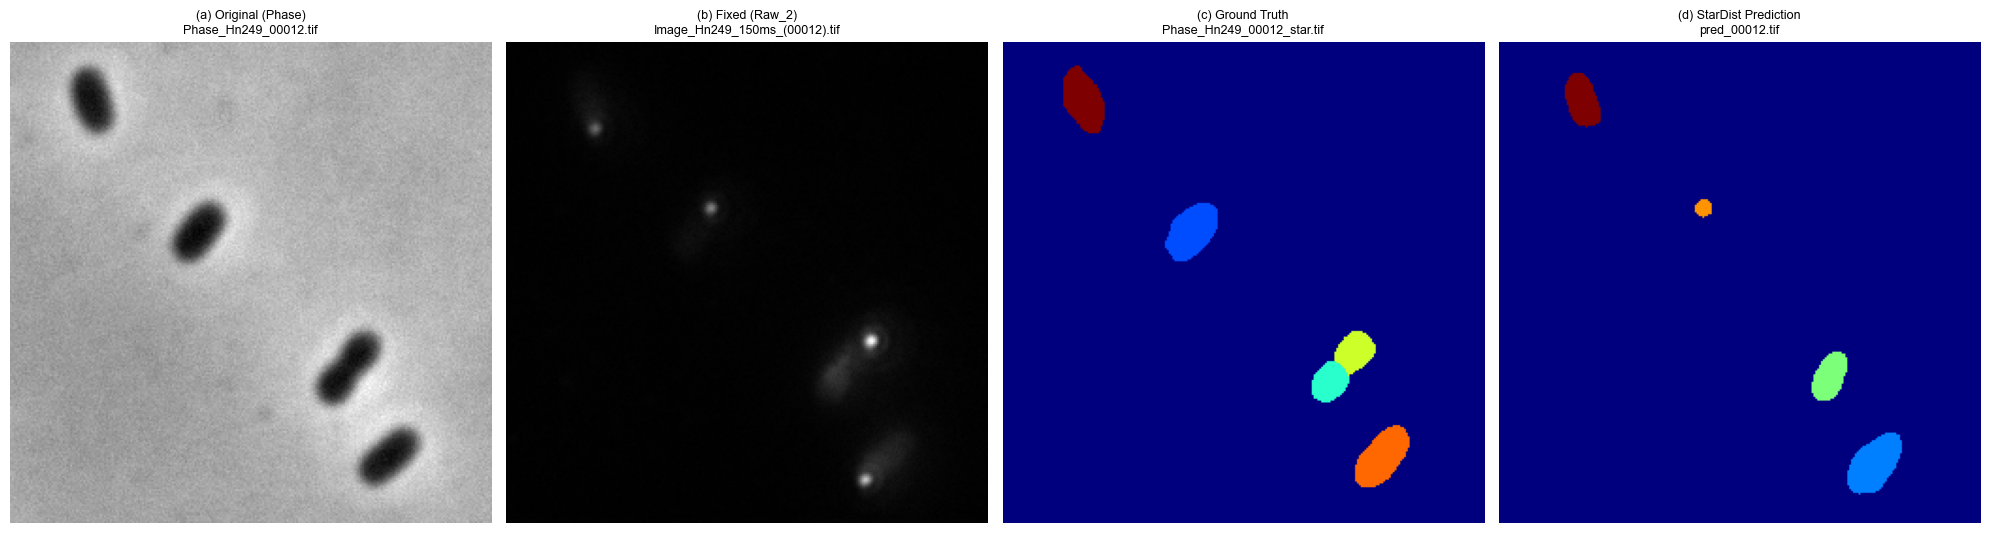

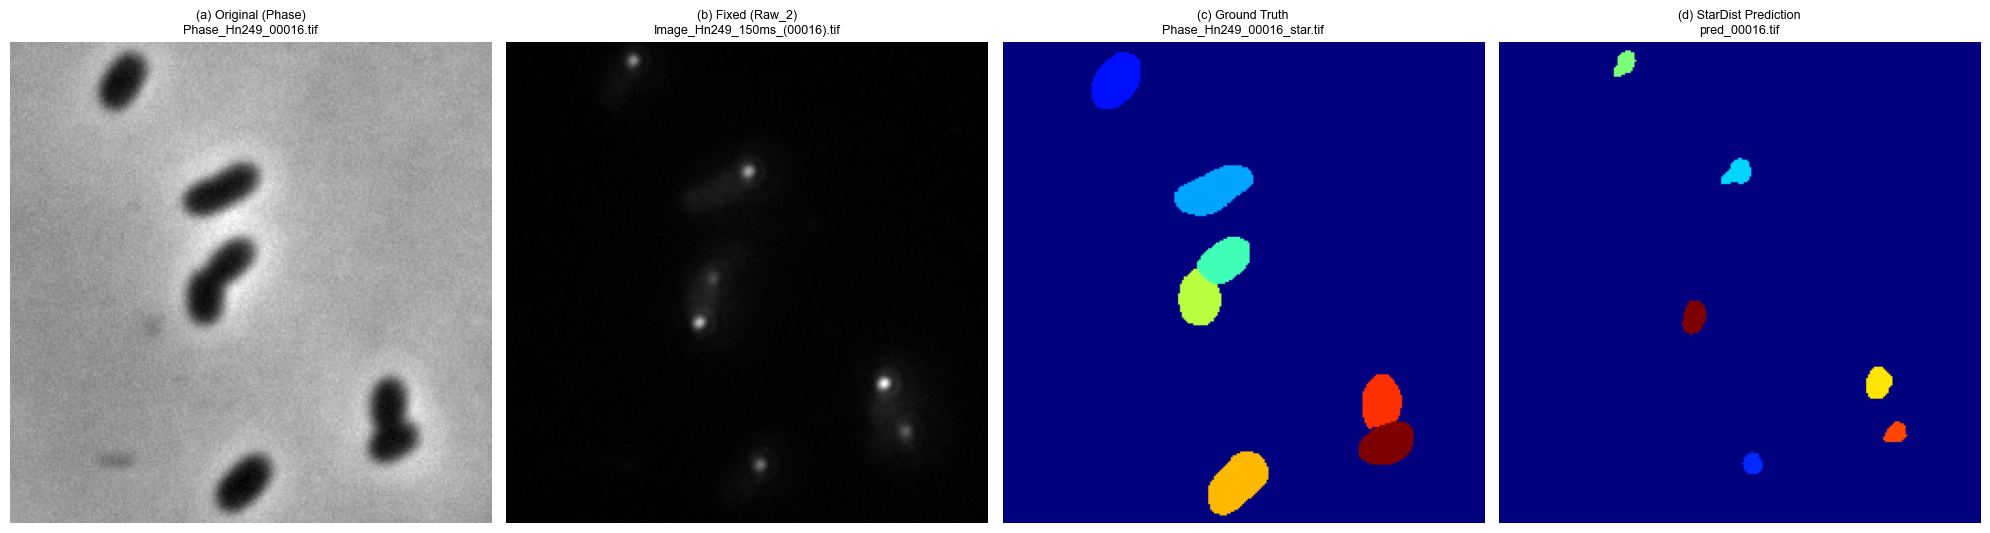

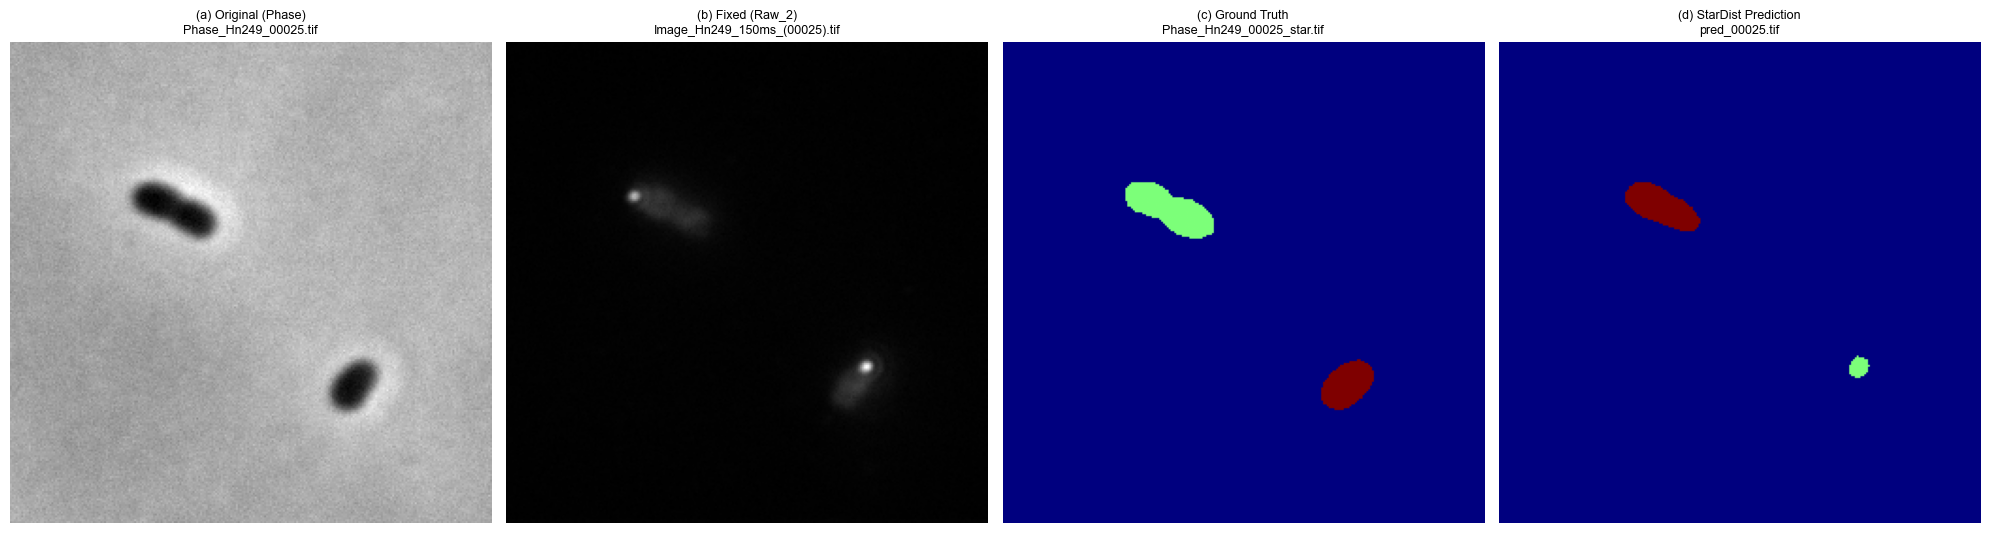

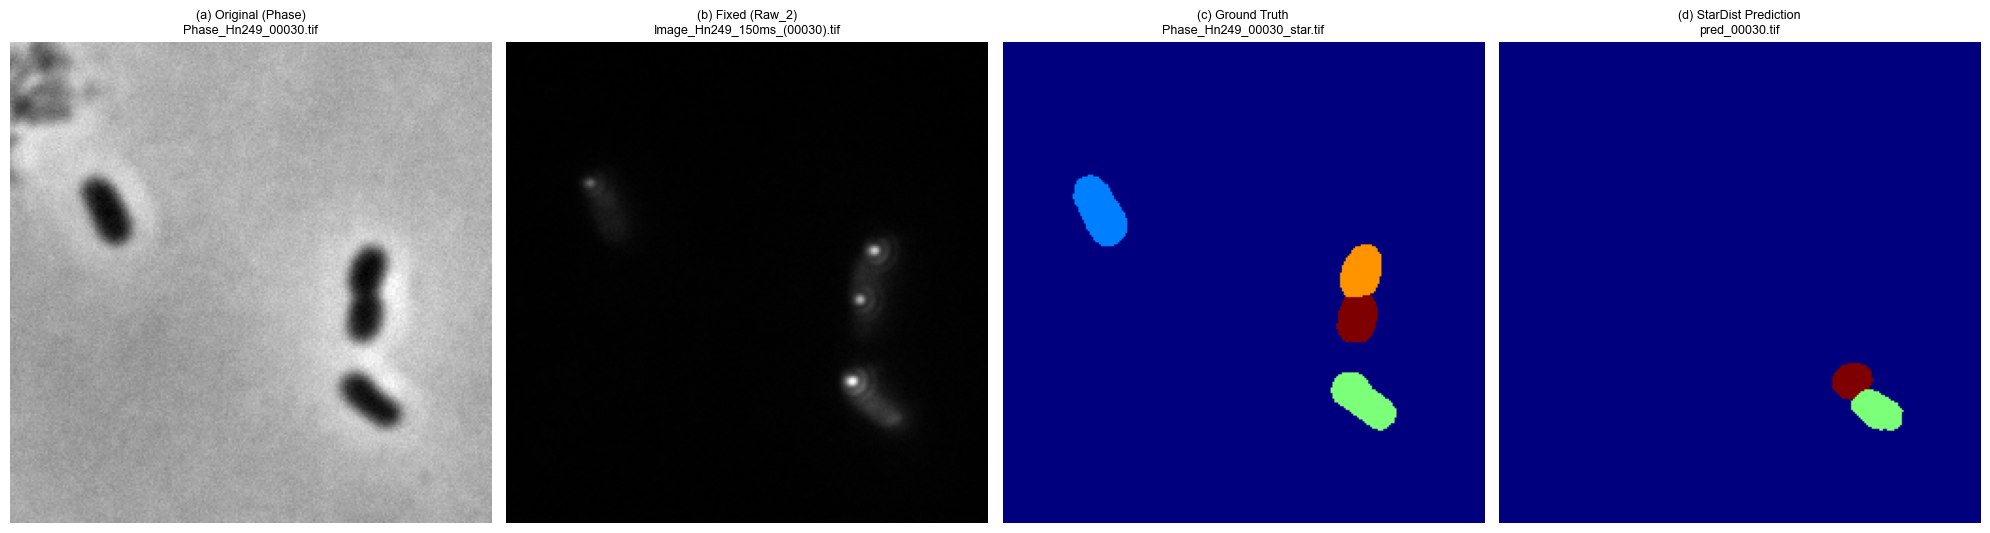

In [37]:
def plot_comparison(idx_str):
    # 1. Setup paths based on your naming conventions
    path_a = os.path.join("phase-contrast_data", f"Phase_Hn249_{idx_str}.tif")
    path_b = os.path.join("fluorescence_data", f"Image_Hn249_150ms_({idx_str}).tif")
    path_c = os.path.join(mask_dir, mask_map.get(idx_str, ""))
    path_d = f"stardist_masks/pred_{idx_str}.tif"

    paths = [path_a, path_b, path_c, path_d]
    titles = ['(a) Original (Phase)', '(b) Fixed (Raw_2)', '(c) Ground Truth', '(d) StarDist Prediction']
    
    plt.figure(figsize=(20, 6))
    
    for i, (p, title) in enumerate(zip(paths, titles)):
        plt.subplot(1, 4, i + 1)
        
        if os.path.exists(p):
            #read and clean up the data
            data = imread(p)
            data = np.squeeze(data)
            if data.ndim == 3:
                data = data[0] 
            
            # Set colormap: Gray for raw images, Jet for label masks
            cmap = 'gray' if i < 2 else 'jet'
            
            # Use vmin/vmax or normalization if the raw images look too dark
            plt.imshow(data, cmap=cmap)
            plt.title(f"{title}\n{os.path.basename(p)}", fontsize=9)
        else:
            plt.text(0.5, 0.5, f'File Not Found:\n{os.path.basename(p)}', 
                     ha='center', va='center', color='red')
            plt.title(title)
            
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Run it
plot_comparison('00001')
plot_comparison('00002')
plot_comparison('00010')
plot_comparison('00011')
plot_comparison('00012')
plot_comparison('00016')
plot_comparison('00025')
plot_comparison('00030')